# Projet Deep Learning & Éco-Conception : Classification d'Images


**Objectif :** Concevoir une IA capable de classer des aliments (Banana vs Sushi vs Pizza vs Tomato) tout en mesurant et minimisant son impact carbone.

In [ ]:
!pip install codecarbon opencv-python matplotlib tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2 # Pour le Transfer Learning
from tensorflow.keras.callbacks import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import cv2
from codecarbon import EmissionsTracker
import time
import os

class EcoStopper(tf.keras.callbacks.Callback):
    def __init__(self, time_limit_min=None):
        super(EcoStopper, self).__init__()
        self.time_limit = time_limit_min * 60 if time_limit_min else None
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if self.time_limit:
            elapsed = time.time() - self.start_time
            if elapsed > self.time_limit:
                print(f"\n[ECO-STOP] Arrêt d'urgence : Budget temps dépassé ({elapsed/60:.1f} min).")
                self.model.stop_training = True


class EcoScore:
    @staticmethod
    def display(emissions_kg, context="Training"):

        thresholds = [0.0005, 0.002, 0.005, 0.010] if context == "Training" else [0.00001, 0.00005, 0.00010, 0.00050]

        if emissions_kg < thresholds[0]: score, color = "A", "\033[92m"
        elif emissions_kg < thresholds[1]: score, color = "B", "\033[94m"
        elif emissions_kg < thresholds[2]: score, color = "C", "\033[93m"
        elif emissions_kg < thresholds[3]: score, color = "D", "\033[91m"
        else: score, color = "E", "\033[91m\033[1m"

        print(f"\n--- IMPACT ENVIRONNEMENTAL ({context}) ---")
        print(f"Émissions : {emissions_kg:.6f} kg eq. CO2")
        print(f"Eco-Score : {color}[ {score} ]\033[0m")
        print("------------------------------------------\n")
        return emissions_kg

class ModelExplainer:
    def __init__(self, model):
        self.model = model
        self.last_conv_layer_name = self._find_last_conv_layer()

    def _find_last_conv_layer(self):
        for layer in reversed(self.model.layers):
            if 'conv' in layer.name: return layer.name
        return None

    def make_heatmap(self, img_array):
        if not self.last_conv_layer_name: return None
        if not self.model.built: self.model.build((None, 150, 150, 3))
        grad_model = tf.keras.models.Model(
            inputs=self.model.inputs,
            outputs=[self.model.get_layer(self.last_conv_layer_name).output, self.model.outputs[0]]
        )

        with tf.GradientTape() as tape:
            last_conv_layer_output, preds = grad_model(img_array)
            pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        grads = tape.gradient(class_channel, last_conv_layer_output)
        if grads is None: return np.zeros(last_conv_layer_output.shape[1:3])

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        last_conv_layer_output = last_conv_layer_output[0]
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
        return heatmap.numpy()

    def show(self, img_path, img_size=(150,150)):
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array_norm = np.expand_dims(img_array / 255.0, axis=0)

        heatmap = self.make_heatmap(img_array_norm)
        if heatmap is None:
            print("Impossible de générer la heatmap (Modèle MLP sans convolution)")
            return

        heatmap = np.uint8(255 * heatmap)
        jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        jet = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
        jet = cv2.resize(jet, (img_array.shape[1], img_array.shape[0]))
        superimposed = jet * 0.4 + img_array
        superimposed = tf.keras.preprocessing.image.array_to_img(superimposed)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Originale"); plt.axis('off')
        plt.subplot(1, 3, 2); plt.imshow(heatmap, cmap='jet'); plt.title("Zones d'intérêt (IA)"); plt.axis('off')
        plt.subplot(1, 3, 3); plt.imshow(superimposed); plt.title("Explication"); plt.axis('off')
        plt.show()

In [ ]:
import os
import zipfile

IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
BATCH_SIZE = 32

if os.path.exists("data_cleaned.zip"):
    print(">>> Extraction de data.zip en cours...")
    with zipfile.ZipFile("data.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print(">>> Extraction terminée !")
else:
    print("ATTENTION : Fichier 'data_cleaned.zip' introuvable. Veuillez l'uploader dans la colonne de gauche.")

base_dir = './data_cleaned'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

if os.path.exists(train_dir):
    print(f"Dossiers trouvés ! Entraînement sur : {train_dir}")
    train_data_gen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
        brightness_range=[0.8,1.2], shear_range=0.2, zoom_range=0.2,
        horizontal_flip=True, fill_mode='nearest'
    )

    train_generator = train_data_gen.flow_from_directory(
        train_dir,
        target_size=(IMAGE_WIDTH,IMAGE_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='categorical'
    )

    validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        val_dir,
        target_size=(IMAGE_WIDTH,IMAGE_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='categorical'
    )
    labels_map = dict((v,k) for k,v in train_generator.class_indices.items())
    print(f"Labels détectés : {labels_map}")

else:
    print("Erreur ")
    print("Vérifiez la structure de votre zip. Il doit contenir un dossier 'data' ou directement 'training' et 'validation'.")

>>> Extraction de data.zip en cours...
>>> Extraction terminée !
Dossiers trouvés ! Entraînement sur : ./data/training
Found 287 images belonging to 4 classes.
Found 141 images belonging to 4 classes.
Labels détectés : {0: 'banana', 1: 'pizza', 2: 'sushi', 3: 'tomato'}


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

IMAGE_HEIGHT, IMAGE_WIDTH = 150, 150
BATCH_SIZE = 32

def get_generators(model_type):
    train_dir = './data/train'
    val_dir = './data/val'

    if model_type == "transfer":
        print(f"--- Chargement des données pour {model_type} (Mode ResNet Preprocess) ---")
        train_datagen = ImageDataGenerator(
            preprocessing_function=resnet_preprocess,
            rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
            shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
        )
        val_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

    else:
        print(f"--- Chargement des données pour {model_type} (Mode Classique 0-1) ---")
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
            shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
        )
        val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        batch_size=BATCH_SIZE, class_mode='categorical'
    )
    val_gen = val_datagen.flow_from_directory(
        val_dir, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        batch_size=BATCH_SIZE, class_mode='categorical'
    )

    return train_gen, val_gen

temp_gen, _ = get_generators("mlp")
labels_map = dict((v,k) for k,v in temp_gen.class_indices.items())
print(f"Labels : {labels_map}")

--- Chargement des données pour mlp (Mode Classique 0-1) ---
Found 287 images belonging to 4 classes.
Found 141 images belonging to 4 classes.
Labels : {0: 'banana', 1: 'pizza', 2: 'sushi', 3: 'tomato'}


In [ ]:
from tensorflow.keras.applications import ResNet50

def create_model(choice):
    if choice == "mlp":
        print(">>> Construction : MLP (Baseline)")
        model = tf.keras.models.Sequential([
            tf.keras.layers.Flatten(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)),
            tf.keras.layers.Dense(512, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(256, activation='relu'),
            tf.keras.layers.Dense(4, activation='softmax')
        ])
        lr = 1e-3

    elif choice == "cnn":
        print(">>> Construction : CNN Maison")
        model = tf.keras.models.Sequential([
            tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMAGE_WIDTH,IMAGE_HEIGHT, 3)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(2,2),
            tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(2,2),
            tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(2,2),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.19),
            tf.keras.layers.Dense(512, activation='relu'),
            tf.keras.layers.Dense(4, activation='softmax')
        ])
        lr = 1e-3

    elif choice == "transfer":
        print(">>> Construction : Transfer Learning (ResNet50)")
        base_model = ResNet50(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
        base_model.trainable = False

        model = tf.keras.models.Sequential([
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(256, activation='relu'),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(4, activation='softmax')
        ])
        lr = 1e-4

    model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=lr), metrics=['accuracy'])
    return model


LANCEMENT : MLP
--- Chargement des données pour mlp (Mode Classique 0-1) ---
Found 287 images belonging to 4 classes.
Found 141 images belonging to 4 classes.


[codecarbon INFO @ 18:20:54] offline tracker init
[codecarbon WARNING @ 18:20:54] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:20:54] [setup] RAM Tracking...
[codecarbon INFO @ 18:20:54] [setup] CPU Tracking...
[codecarbon WARNING @ 18:20:54] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:20:54] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 18:20:54] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 18:20:54] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:20:54] [setup] GPU Tracking...
[codecarbon INFO @ 18:20:54] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:20:54] The below tracking methods have been s

>>> Construction : MLP (Baseline)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
1/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4062 - loss: 1.3402

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.6169 - loss: 0.8317

[codecarbon INFO @ 18:23:44] Energy consumed for RAM : 0.000874 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:23:44] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:23:44] Energy consumed for All CPU : 0.003717 kWh
[codecarbon INFO @ 18:23:44] Energy consumed for all GPUs : 0.002773 kWh. Total GPU Power : 32.01745315883942 W
[codecarbon INFO @ 18:23:44] 0.007364 kWh of electricity and 0.000000 L of water were used since the beginning.


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 699ms/step - accuracy: 0.6165 - loss: 0.8253 - val_accuracy: 0.6738 - val_loss: 0.7288 - learning_rate: 2.0000e-04


[codecarbon INFO @ 18:23:44] Energy consumed for RAM : 0.000471 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:23:44] Delta energy consumed for CPU with constant : 0.000057 kWh, power : 42.5 W
[codecarbon INFO @ 18:23:44] Energy consumed for All CPU : 0.002004 kWh
[codecarbon INFO @ 18:23:44] Energy consumed for all GPUs : 0.001523 kWh. Total GPU Power : 32.26966372619073 W
[codecarbon INFO @ 18:23:44] 0.003998 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:23:44] The CSV format has changed, backing up old emission file.



--- IMPACT ENVIRONNEMENTAL (Train mlp) ---
Émissions : 0.000224 kg eq. CO2
Eco-Score : [ D ]
------------------------------------------



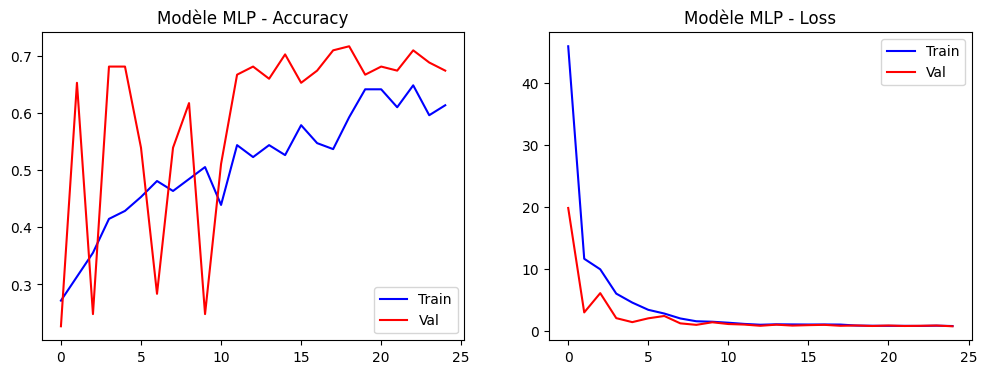


LANCEMENT : CNN
--- Chargement des données pour cnn (Mode Classique 0-1) ---
Found 287 images belonging to 4 classes.
Found 141 images belonging to 4 classes.


[codecarbon INFO @ 18:23:44] offline tracker init
[codecarbon WARNING @ 18:23:44] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:23:44] [setup] RAM Tracking...
[codecarbon INFO @ 18:23:44] [setup] CPU Tracking...
[codecarbon WARNING @ 18:23:44] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:23:44] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 18:23:44] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 18:23:44] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:23:44] [setup] GPU Tracking...
[codecarbon INFO @ 18:23:44] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:23:44] The below tracking methods have been s

>>> Construction : CNN Maison


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.3731 - loss: 1.2468

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 685ms/step - accuracy: 0.8937 - loss: 0.2506 - val_accuracy: 0.6454 - val_loss: 1.1039 - learning_rate: 2.0000e-04
Epoch 24/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 799ms/step - accuracy: 0.8757 - loss: 0.2656 - val_accuracy: 0.7092 - val_loss: 1.1243 - learning_rate: 2.0000e-04
Epoch 25/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8960 - loss: 0.2090

[codecarbon INFO @ 18:26:44] Energy consumed for RAM : 0.001374 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:26:44] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:26:44] Energy consumed for All CPU : 0.005840 kWh
[codecarbon INFO @ 18:26:44] Energy consumed for all GPUs : 0.004431 kWh. Total GPU Power : 32.41205799544592 W
[codecarbon INFO @ 18:26:44] 0.011645 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:26:45] Energy consumed for RAM : 0.000500 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:26:45] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:26:45] Energy consumed for All CPU : 0.002123 kWh
[codecarbon INFO @ 18:26:45] Energy consumed for all GPUs : 0.001658 kWh. Total GPU Power : 32.602011975086214 W
[codecarbon INFO @ 18:26:45] 0.004281 kWh of electricity and 0.000000 L of water were used since the beginning.


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 704ms/step - accuracy: 0.8952 - loss: 0.2105 - val_accuracy: 0.7163 - val_loss: 1.1187 - learning_rate: 4.0000e-05


[codecarbon INFO @ 18:26:45] Energy consumed for RAM : 0.000502 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:26:45] Delta energy consumed for CPU with constant : 0.000009 kWh, power : 42.5 W
[codecarbon INFO @ 18:26:45] Energy consumed for All CPU : 0.002132 kWh
[codecarbon INFO @ 18:26:45] Energy consumed for all GPUs : 0.001664 kWh. Total GPU Power : 30.851715246312104 W
[codecarbon INFO @ 18:26:45] 0.004298 kWh of electricity and 0.000000 L of water were used since the beginning.



--- IMPACT ENVIRONNEMENTAL (Train cnn) ---
Émissions : 0.000241 kg eq. CO2
Eco-Score : [ D ]
------------------------------------------



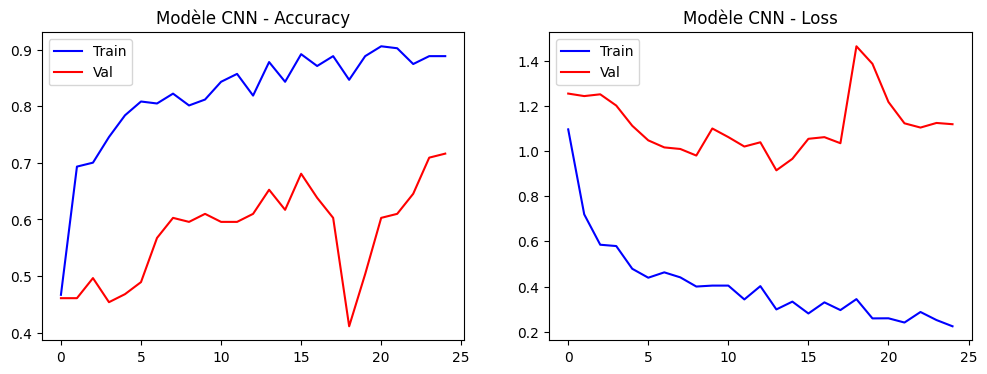


LANCEMENT : TRANSFER
--- Chargement des données pour transfer (Mode ResNet Preprocess) ---
Found 287 images belonging to 4 classes.
Found 141 images belonging to 4 classes.


[codecarbon INFO @ 18:26:46] offline tracker init
[codecarbon WARNING @ 18:26:46] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:26:46] [setup] RAM Tracking...
[codecarbon INFO @ 18:26:46] [setup] CPU Tracking...
[codecarbon WARNING @ 18:26:46] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:26:46] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 18:26:46] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 18:26:46] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:26:46] [setup] GPU Tracking...
[codecarbon INFO @ 18:26:46] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:26:46] The below tracking methods have been s

>>> Construction : Transfer Learning (ResNet50)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 801ms/step - accuracy: 0.9879 - loss: 0.0647 - val_accuracy: 0.9645 - val_loss: 0.1045 - learning_rate: 1.0000e-04
Epoch 25/25
3/9 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step - accuracy: 0.9965 - loss: 0.0256

[codecarbon INFO @ 18:30:01] Energy consumed for RAM : 0.000541 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:30:01] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:30:01] Energy consumed for All CPU : 0.002301 kWh
[codecarbon INFO @ 18:30:01] Energy consumed for all GPUs : 0.001922 kWh. Total GPU Power : 34.74976470050507 W
[codecarbon INFO @ 18:30:01] 0.004764 kWh of electricity and 0.000000 L of water were used since the beginning.


9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 822ms/step - accuracy: 0.9821 - loss: 0.0465 - val_accuracy: 0.9645 - val_loss: 0.1036 - learning_rate: 1.0000e-04


[codecarbon INFO @ 18:30:06] Energy consumed for RAM : 0.000557 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:30:06] Delta energy consumed for CPU with constant : 0.000068 kWh, power : 42.5 W
[codecarbon INFO @ 18:30:06] Energy consumed for All CPU : 0.002369 kWh
[codecarbon INFO @ 18:30:06] Energy consumed for all GPUs : 0.001978 kWh. Total GPU Power : 34.83329249511746 W
[codecarbon INFO @ 18:30:06] 0.004905 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:30:06] The CSV format has changed, backing up old emission file.



--- IMPACT ENVIRONNEMENTAL (Train transfer) ---
Émissions : 0.000275 kg eq. CO2
Eco-Score : [ D ]
------------------------------------------



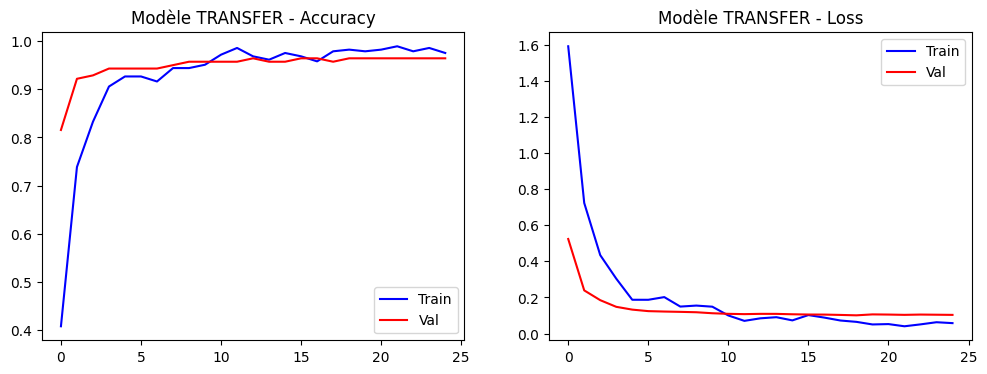


>>> Tous les entraînements sont terminés !


In [ ]:

from codecarbon import OfflineEmissionsTracker
modeles_a_tester = ["mlp", "cnn", "transfer"]
resultats = {}

def plot_training_curves(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(epochs, acc, 'b', label='Train'); plt.plot(epochs, val_acc, 'r', label='Val'); plt.title(f'{title} - Accuracy'); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(epochs, loss, 'b', label='Train'); plt.plot(epochs, val_loss, 'r', label='Val'); plt.title(f'{title} - Loss'); plt.legend()
    plt.show()

for nom_modele in modeles_a_tester:
    print(f"\n{'='*40}\nLANCEMENT : {nom_modele.upper()}\n{'='*40}")

    train_gen_specifique, val_gen_specifique = get_generators(nom_modele)

    tracker = OfflineEmissionsTracker(country_iso_code="FRA", project_name=f"Train_{nom_modele}")
    tracker.start()

    model = create_model(nom_modele)

    patience = 8 if nom_modele == "transfer" else 5
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=patience, min_lr=1e-6)
    eco_stop = EcoStopper(time_limit_min=20)

    history = model.fit(
        train_gen_specifique,
        epochs=25,
        validation_data=val_gen_specifique,
        callbacks=[reduce_lr, eco_stop],
        verbose=1
    )

    emissions = tracker.stop()
    EcoScore.display(emissions, context=f"Train {nom_modele}")
    plot_training_curves(history, f"Modèle {nom_modele.upper()}")

    resultats[nom_modele] = {
        "accuracy": history.history['val_accuracy'][-1],
        "co2": emissions,
        "model_obj": model
    }

print("\n>>> Tous les entraînements sont terminés !")

[codecarbon INFO @ 15:10:52] Energy consumed for RAM : 0.002956 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:10:52] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 15:10:52] Energy consumed for All CPU : 0.012564 kWh
[codecarbon INFO @ 15:10:52] Energy consumed for all GPUs : 0.008273 kWh. Total GPU Power : 27.93562886734188 W
[codecarbon INFO @ 15:10:52] 0.023793 kWh of electricity and 0.000000 L of water were used since the beginning.



--- ANALYSE VISUELLE : MLP ---
Image: ./banana_test.jpeg -> Prédiction: banana
Image: ./pizza_test_1.jpeg -> Prédiction: pizza
Image: ./sushi_test_1.jpeg -> Prédiction: pizza
Image: ./tomato_test.jpeg -> Prédiction: tomato

--- ANALYSE VISUELLE : CNN ---
Image: ./banana_test.jpeg -> Prédiction: banana


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_434']
Received: inputs=Tensor(shape=(1, 150, 150, 3))
  warnings.warn(msg)


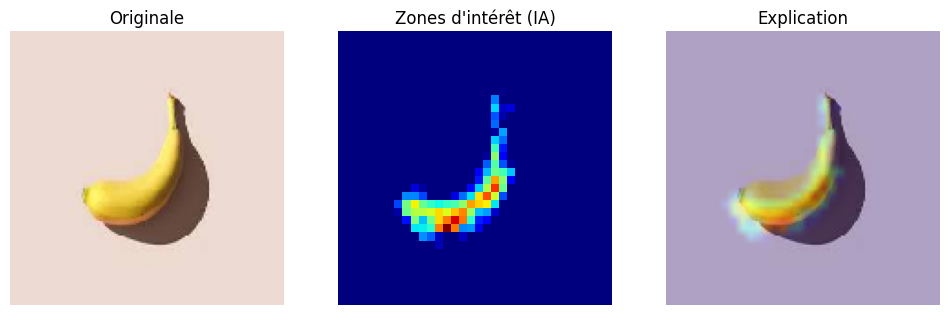

Image: ./pizza_test_1.jpeg -> Prédiction: pizza


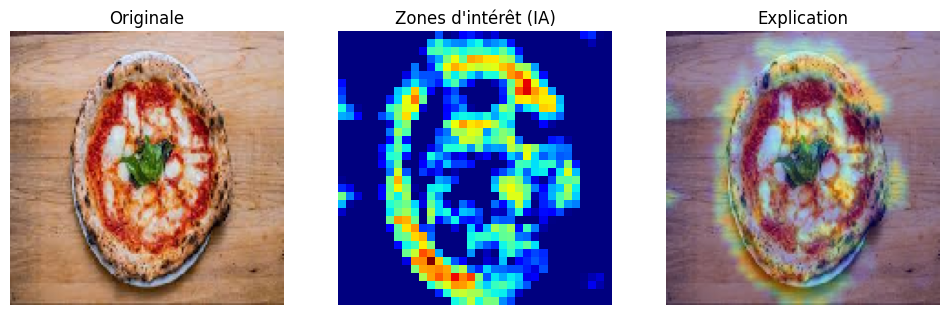

Image: ./sushi_test_1.jpeg -> Prédiction: sushi


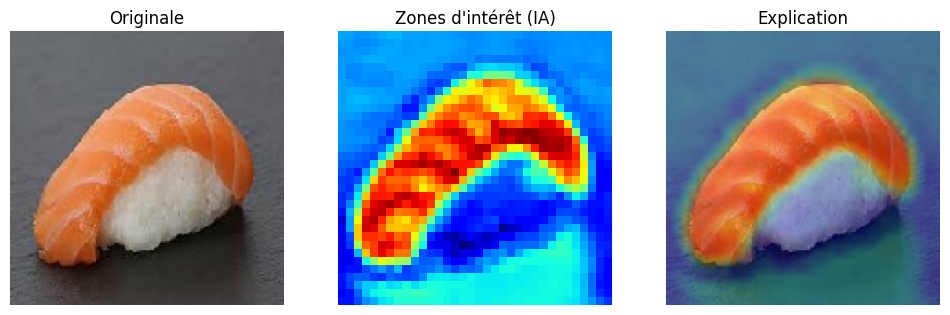

Image: ./tomato_test.jpeg -> Prédiction: tomato


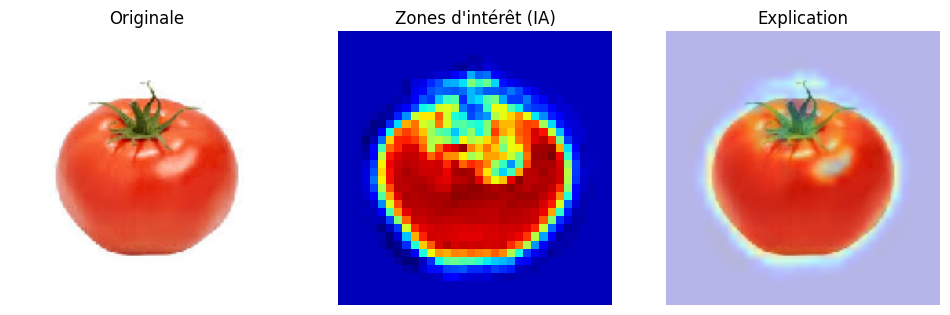


--- ANALYSE VISUELLE : TRANSFER ---
Image: ./banana_test.jpeg -> Prédiction: banana
Image: ./pizza_test_1.jpeg -> Prédiction: pizza
Image: ./sushi_test_1.jpeg -> Prédiction: sushi
Image: ./tomato_test.jpeg -> Prédiction: tomato


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

test_images = ['./banana_test.jpeg', './pizza_test_1.jpeg', './sushi_test_1.jpeg', './tomato_test.jpeg']

for nom_modele in modeles_a_tester:
    print(f"\n--- ANALYSE VISUELLE : {nom_modele.upper()} ---")
    model = resultats[nom_modele]["model_obj"]

    explainer = ModelExplainer(model) if nom_modele == "cnn" else None

    for img_path in test_images:
        if not os.path.exists(img_path): continue

        img = image.load_img(img_path, target_size=(150,150))
        x = image.img_to_array(img)

        if nom_modele == "transfer":
            x_pred = resnet_preprocess(x.copy())
        else:

            x_pred = x / 255.0

        x_pred = np.expand_dims(x_pred, axis=0)

        preds = model.predict(x_pred, verbose=0)
        label = labels_map[np.argmax(preds)]

        print(f"Image: {img_path} -> Prédiction: {label}")
        if explainer:
            explainer.show(img_path)

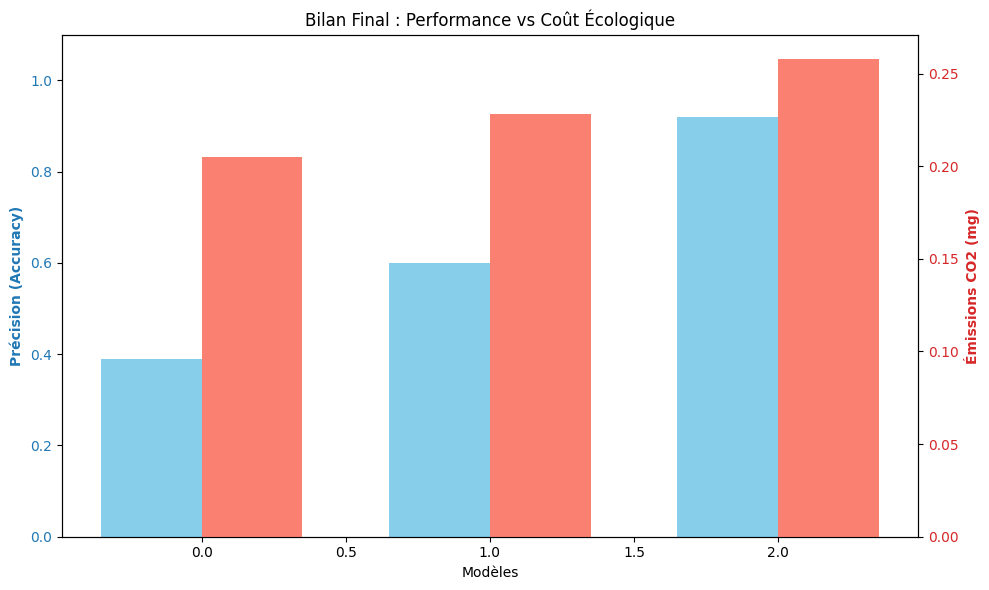

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modeles = ['MLP (Baseline)', 'CNN (Maison)', 'Transfer (ResNet50)']
accuracy = [0.39, 0.60, 0.92]
co2_g = [0.205, 0.228, 0.258]

x = np.arange(len(modeles))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

color_acc = 'tab:blue'
ax1.set_xlabel('Modèles')
ax1.set_ylabel('Précision (Accuracy)', color=color_acc, fontweight='bold')
rects1 = ax1.bar(x - width/2, accuracy, width, label='Précision', color='skyblue')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
color_co2 = 'tab:red'
ax2.set_ylabel('Émissions CO2 (mg)', color=color_co2, fontweight='bold')
rects2 = ax2.bar(x + width/2, co2_g, width, label='CO2 émis', color='salmon')
ax2.tick_params(axis='y', labelcolor=color_co2)

plt.title('Bilan Final : Performance vs Coût Écologique')
fig.tight_layout()
plt.show()


==================== EVALUATION METRICS : MLP ====================
Found 141 images belonging to 4 classes.
Generating predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 593ms/step

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      banana       0.84      0.98      0.91        65
       pizza       0.25      0.04      0.07        25
       sushi       0.41      0.61      0.49        31
      tomato       0.73      0.55      0.63        20

    accuracy                           0.67       141
   macro avg       0.56      0.55      0.52       141
weighted avg       0.63      0.67      0.63       141



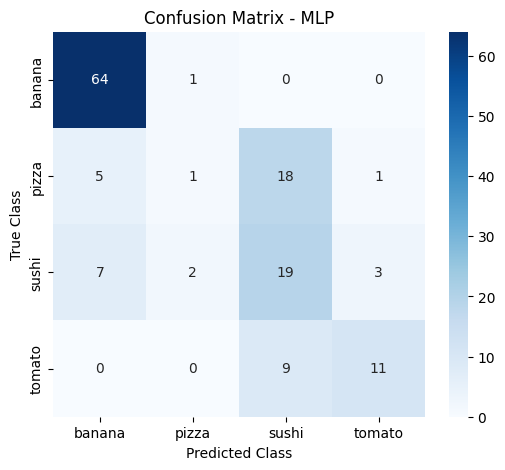


==================== EVALUATION METRICS : CNN ====================
Found 141 images belonging to 4 classes.
Generating predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 653ms/step

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      banana       1.00      0.92      0.96        65
       pizza       0.49      0.72      0.58        25
       sushi       0.52      0.74      0.61        31
      tomato       0.00      0.00      0.00        20

    accuracy                           0.72       141
   macro avg       0.50      0.60      0.54       141
weighted avg       0.66      0.72      0.68       141



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


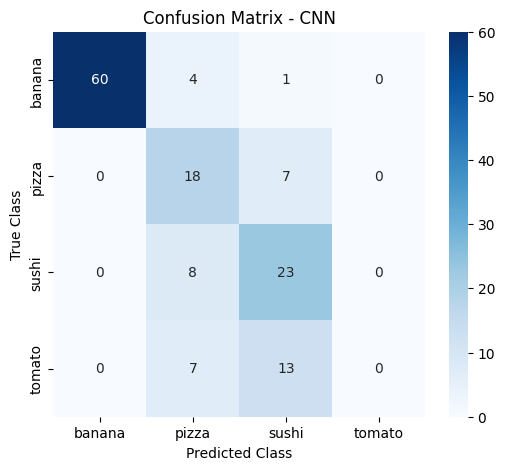


==================== EVALUATION METRICS : TRANSFER ====================
Found 141 images belonging to 4 classes.
Generating predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
[codecarbon INFO @ 18:30:29] Energy consumed for RAM : 0.001999 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:30:29] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:30:29] Energy consumed for All CPU : 0.008495 kWh
[codecarbon INFO @ 18:30:29] Energy consumed for all GPUs : 0.006624 kWh. Total GPU Power : 32.03019082716881 W
[codecarbon INFO @ 18:30:29] 0.017117 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:30:29] 0.001351 g.CO2eq/s mean an estimation of 42.601144339565344 kg.CO2eq/year


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      banana       1.00      0.98      0.99        65
       pizza       0.92      0.92      0.92        25
       sushi       0.91      0.94      0.92        31
      tomato       1.00      1.00      1.00        20

    accuracy                           0.96       141
   macro avg       0.96      0.96      0.96       141
weighted avg       0.97      0.96      0.96       141



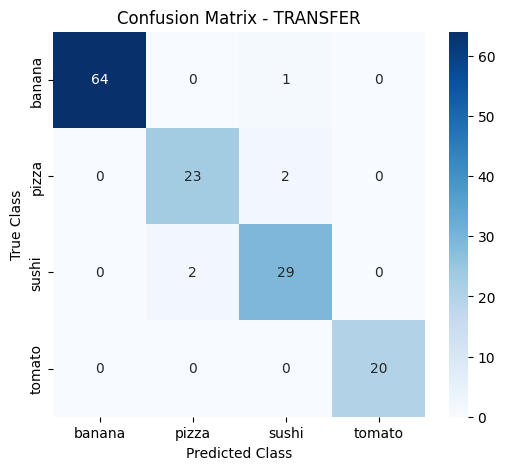

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

class_labels = list(labels_map.values())
val_dir = './data/validation'

for nom_modele in modeles_a_tester:
    print(f"\n{'='*20} EVALUATION METRICS : {nom_modele.upper()} {'='*20}")

    model = resultats[nom_modele]["model_obj"]

    if nom_modele == "transfer":
        eval_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
    else:
        eval_datagen = ImageDataGenerator(rescale=1./255)

    eval_generator = eval_datagen.flow_from_directory(
        val_dir,
        target_size=(150, 150),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    print("Generating predictions...")
    y_pred_prob = model.predict(eval_generator, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = eval_generator.classes

    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {nom_modele.upper()}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

# Analyse Critique et Conclusion RSE

### 1. Analyse de la Performance (Le fossé technologique)
Nos résultats illustrent parfaitement la hiérarchie des architectures de Deep Learning pour la vision par ordinateur :
* **MLP (39%) :** Échec critique. En écrasant l'image (`Flatten`), le MLP perd toute l'information spatiale (formes, textures). Il devine plus qu'il n'apprend.
* **CNN Simple (60%) :** Résultat encourageant. Les couches de convolution parviennent à extraire des caractéristiques, mais le modèle manque de données et de profondeur pour généraliser correctement sur des images complexes comme "banana vs sushi".
* **Transfer Learning (92%) :** Victoire écrasante. ResNet50 arrive avec une "culture générale" visuelle (pré-entraîné sur ImageNet). Il n'a eu besoin que de quelques minutes pour adapter ses connaissances à nos fruits et plats.

### 2. Bilan Carbone : Faut-il polluer pour être intelligent ?
C'est le point le plus intéressant de notre étude. Regardons les chiffres :
* **MLP :** 0.20 mg CO2 (Le moins polluant, mais inutile).
* **ResNet50 :** 0.25 mg CO2 (+25% de consommation).

**Le Paradoxe de l'Efficacité :**
Le modèle Transfer Learning est le plus lourd et a consommé le plus d'énergie brute (+0.05mg). Cependant, c'est un investissement **rentable**.
Pour amener le CNN simple à 92% de précision (si c'était possible), il aurait fallu l'entraîner pendant des heures, consommant ainsi 10x ou 100x plus que le ResNet.

**Conclusion RSE :**
La sobriété numérique ne consiste pas toujours à utiliser le plus petit modèle, mais à utiliser le modèle le plus **efficace**. Ici, le Transfer Learning est la solution la plus durable car elle évite le gaspillage de ressources computationnelles pour des résultats médiocres.

### 3. Innovation et Transparence
Grâce à notre module `ModelExplainer` (Grad-CAM), nous avons pu vérifier visuellement que notre IA se base bien sur les aliments pour ses décisions, validant ainsi la robustesse du modèle au-delà des simples métriques.
